# Лабораторная работа №3
Работа с видеопотоком

In [88]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Загрузим изображение

Видео успешно загружено!


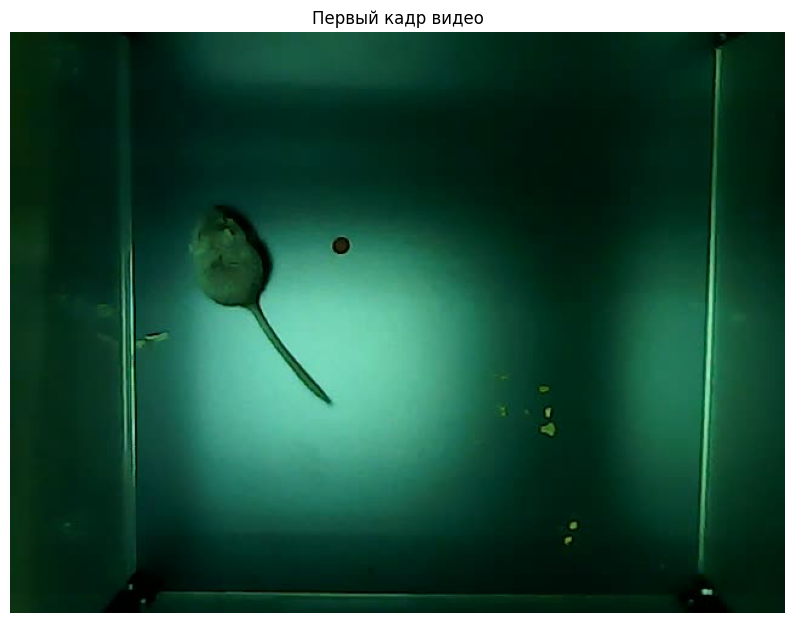

In [89]:
# Загружаем видео для обработки
cap = cv2.VideoCapture("mouse_1.avi")

# Проверяем, загрузилось ли видео
if not cap.isOpened():
    print("Ошибка: не удалось загрузить видео")
else:
    print("Видео успешно загружено!")
    success, img3=cap.read()
    if success:
        img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
        
        # Отображаем изображение
        plt.figure(figsize=(10, 8))
        plt.imshow(img3_rgb)
        plt.axis('off')  # Скрываем оси
        plt.title('Первый кадр видео')
        plt.show()
    else:
        print("Не удалось прочитать кадр")


Решим поставленную задачу следующим образом. Разделим Видеопоток покадрово, усредним, а после удалим фон (можем удалить так как мышь двигается на постоянном фоне), бинаризуем изображение и найдем центр масс мыши. Далее, составим траекторию движения мыши убрав шум и нулевые значения.

Переведем видеопоток в оттенки серого для упрощения работы с ними

In [90]:
#Создание массива всего видео в виде кадров
check, img = cap.read()
frames = []
if check:
    i = 1
    while(check):
        check, img = cap.read()
        if(check):
            img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            frames.append(img_grey)
cap.release()
print(f"Загружено {len(frames)} кадров")

Загружено 6074 кадров


In [91]:
frames[4000] #Проверяем количество кадров (есть ли 4000 кадр)

array([[74, 73, 71, ..., 59, 59, 59],
       [74, 72, 70, ..., 59, 59, 59],
       [72, 70, 70, ..., 59, 59, 59],
       ...,
       [82, 82, 82, ..., 53, 53, 53],
       [82, 82, 82, ..., 53, 53, 53],
       [82, 82, 82, ..., 53, 53, 53]], shape=(480, 640), dtype=uint8)

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

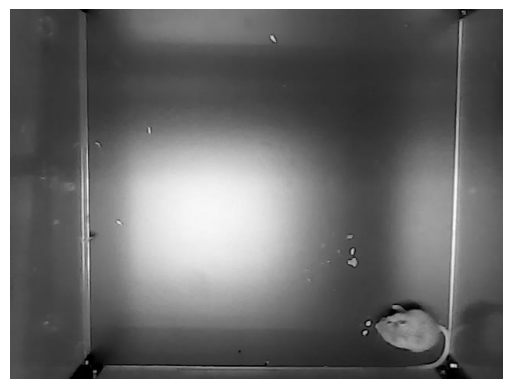

In [92]:

img_0 = cv2.cvtColor(frames[3090], cv2.COLOR_BGR2RGB)
plt.imshow(img_0)
plt.axis('off')



Поскольку фон остается статичным, оптимальным подходом к решению задачи является построение модели фона. Начнем с реализации простейшего метода — усреднения фона. В реальных условиях этот метод обычно неприменим, так как требует накопления информации о всех кадрах для усреднения пикселей. Однако в нашем конкретном примере такие данные доступны изначально, что позволяет использовать данный подход.

In [93]:
def sr_mod_fon(arr_image): #функция среднего фона
    mod_fon = np.zeros(arr_image[1].shape, dtype='uint8')
    sum_arr = np.zeros(arr_image[0].shape, dtype=np.float64)
    num_frames = len(arr_image) - 10
    
    for k in range(len(arr_image) - 10):
        image = arr_image[k]
        for i in range(len(image)):
            for j in range(len(image[i])):
                sum_arr[i, j] = sum_arr[i, j] + image[i, j]
        print(k)
    
    sum_arr = sum_arr / num_frames
    return sum_arr

In [94]:
#Выделение медианного значения для каждого пикселя (наиболее общего кадра) из массива
def median_image (frames):
    quan = len(frames)
    h, w  = frames[0].shape
    newimg = np.zeros((h,w),dtype=frames[0].dtype)
    for j in range (h):
        for k in range (w):
            hist = np.zeros(256, dtype=np.uint32)
            for i in range (quan):
                hist[frames[i][j][k]] += 1
            newimg[j][k] = np.argmax(hist)
    return newimg

In [95]:
#amt=sr_mod_fon(frames) # Проверка
amt=median_image(frames)

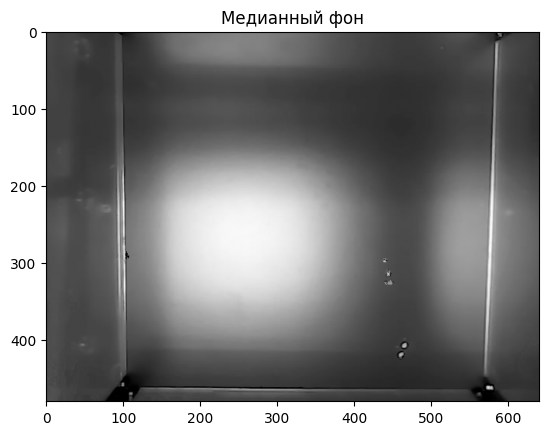

In [96]:
plt.imshow(amt, cmap='gray')
plt.title('Медианный фон')
plt.show()

Округлим значения пикселей. Для этого используем np требуемый формат изображения, а именно np.uint8

In [97]:
new=np.int16(amt)

In [120]:
def only_mouse(diff_image):
    ret,thresh = cv2.threshold(diff_image, 40, 255,cv2.THRESH_BINARY) # Бинаризация
    thresh=cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((7,7),np.uint8), iterations=1) # Открытие/Удаление шума
    thresh=cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((7,7),np.uint8), iterations=1) # Закрытие
    return thresh

Бинаризируем картинку для поиска центра масс

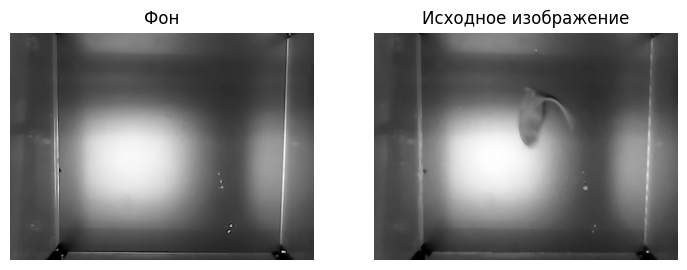

In [99]:
img1 = frames[2001].copy()

med_equl1 = cv2.medianBlur(img1.copy(), 7)

plt.figure(figsize=(18, 10))

plt.subplot(2, 4, 1)
plt.imshow(amt, cmap='gray')
plt.title("Фон")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(med_equl1, cmap='gray')
plt.title("Исходное изображение")
plt.axis('off')

plt.show()

In [100]:
def addWeighted(image1, image2):
    diff = image2.astype(np.int16) - image1.astype(np.int16)
    # Берём абсолютное значение
    abs_diff = np.abs(diff)
    # Приводим обратно к uint8 (обрезаем значения >255)
    return np.clip(abs_diff, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

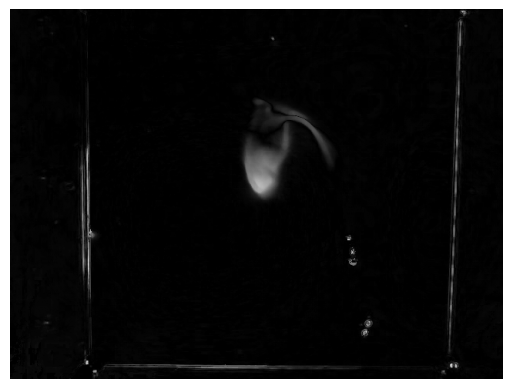

In [101]:
diff_image=addWeighted(med_equl1,amt)
plt.imshow(diff_image, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

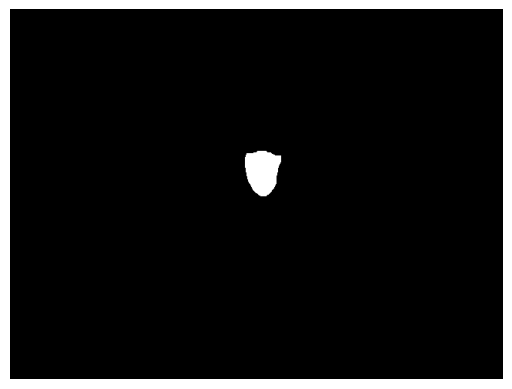

In [121]:
mouse = only_mouse(diff_image)
plt.imshow(mouse, cmap='gray')
plt.axis('off')

In [122]:
def mod_fon (arr_image): #Вычислим центр масс для массива
  mod_fon = np.zeros(arr_image[1].shape, dtype='uint8') # Создаем модель фона
  mom=[None]*len(arr_image) #Создаем пустой массив
  for k in range(len(arr_image)-10): # Обозначаем мимнимальный размер
    mod_fon=cv2.addWeighted(arr_image[k],0.5,mod_fon,0.5,0) # Обновление фона
    diff_image=cv2.addWeighted(arr_image[k],1,mod_fon,-1,0) # Вычитание фона
    ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY) # Бинаризация
    mu=cv2.moments(thresh)
    mom[k]=(mu['m10'] / (mu['m00'] + 1e-2), mu['m01'] / (mu['m00'] + 1e-2)) # Определение центра масс
    if(mom[k][0]==0 and mom[k][1]==0): # Убираем нулевые центры (берем предыдущие)
      mom[k]=mom[k-1]
    if(k!=0):
      if((mom[k][0]-mom[k-1][0])>30 or (mom[k][1]-mom[k-1][1])>30):  # Фильтруем скачки
        mom[k]=mom[k-1]
  return mom

In [123]:
def mod_fon (arr_image, img_median): # 1-список кадров, 2-фон
    mod_fon = np.zeros(arr_image[0].shape, dtype='uint8') #создаем пустой массив
    mom=[None]*len(arr_image) # создаем пустой список для записи
    for k in range(len(arr_image)):
        n = 7 #размер ядра свертки 
        med_equl1 = cv2.medianBlur(img_median.copy(), n)
        med_equl2 = cv2.medianBlur(arr_image[k].copy(), n)
        equalized1 = cv2.equalizeHist(med_equl1.copy())
        equalized2 = cv2.equalizeHist(med_equl2.copy())
        diff_image1 = addWeighted(equalized1.copy(),equalized2.copy()) # Вычитаем фон
        mouse = only_mouse(diff_image1) # Выписываем бинаризованную мышь
        mu=cv2.moments(mouse) # Чекаем моменты
        mom[k]=(mu['m10'] / (mu['m00'] + 1e-2), mu['m01'] / (mu['m00'] + 1e-2)) # вычисляем центр масс
        if(mom[k][0]==0 and mom[k][1]==0):
            mom[k]=mom[k-1]
    return mom

In [124]:
data=mod_fon(frames, amt)

In [125]:
D1=[None]*len(data)
D2=[None]*len(data)
for k in range(len(data)):
  D1[k] = data[k][0]
  D2[k] = data[k][1]



In [126]:
def video(x,y, frames):
    data_end = []
    for k in range(len(frames)):
        img = cv2.circle(frames[k], center=(round(x[k]), round(y[k])), radius=10, color=(0, 120, 120), thickness=None, lineType=None, shift=None)
        data_end.append(img)
    return data_end
data_v = video(D1, D2, frames)

In [127]:
height, width = data_v[0].shape[:2]

video = cv2.VideoWriter('myvideo.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 25,  (width, height))

for frame in data_v:
    video.write(frame)

video.release()



In [128]:
height, width = data_v[0].shape[:2]

# Создаём VideoWriter
video = cv2.VideoWriter('myvideo.avi', 
                        cv2.VideoWriter_fourcc(*'XVID'),  # XVID надёжнее
                        25, 
                        (width, height))

for frame in data_v:
    # 1. Проверяем и конвертируем в BGR если нужно
    if len(frame.shape) == 2:
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    elif frame.shape[2] == 4:  # Если RGBA (4 канала)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2BGR)
    
    # 2. Проверяем тип данных
    if frame.dtype != np.uint8:
        frame = frame.astype(np.uint8)
    
    # 3. Проверяем размер
    if frame.shape[:2] != (height, width):
        frame = cv2.resize(frame, (width, height))
    
    video.write(frame)

video.release()
print("Видео сохранено как 'myvideo.avi'")

Видео сохранено как 'myvideo.avi'


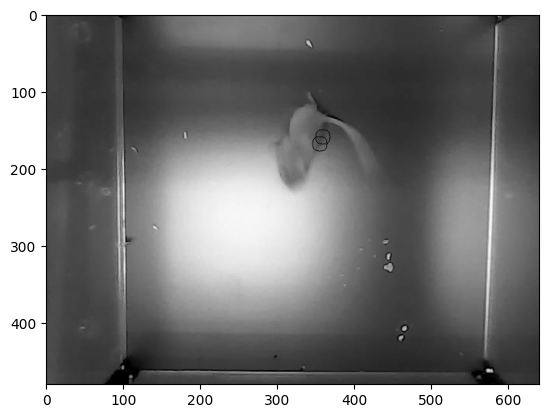

In [129]:
plt.imshow(data_v[2000], cmap='gray')

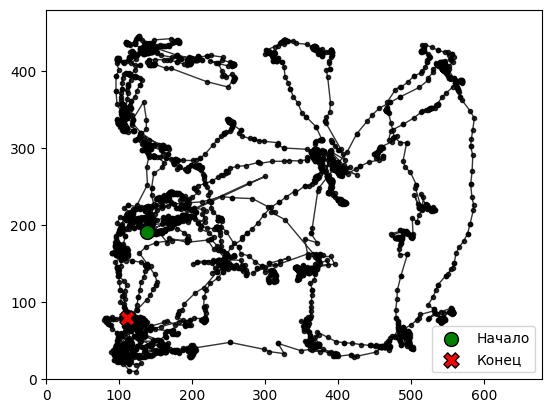

In [130]:
plt.xlim(0, 680) 
plt.ylim(0, 480) 
plt.plot(D1, D2, color='black', marker='.', linewidth=1, alpha=0.8)

# Стартовая точка (первый кадр)
plt.scatter(D1[0], D2[0], color='green', s=100, edgecolors='black', 
            zorder=5, label='Начало')

# Конечная точка (последний кадр)
plt.scatter(D1[-1], D2[-1], color='red', s=120, marker='X', 
            edgecolors='black', zorder=5, label='Конец')
plt.legend()
plt.show()